# CIP-Swiss-Airports - Final analysis

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import  matplotlib.pyplot as plt

In [5]:
# Load and concatenate cleaned CSV files from the different airports specified folder
df_basel = pd.read_csv("../Basel/data/combined_cleaned_flight_data.csv")
df_geneva = pd.read_csv("../Geneva/data/combined_cleaned_data.csv")
df_zurich = pd.read_csv("../Zurich/data/combined_zurich_airport.csv")

In [6]:
df_basel.head(2)

,Type,LocalAirport,ForeignAirport,Airline,PlannedDate,ActualDate,Delay
0,Arrivals,Basel,Paris Charles De Gaulle,FedEx,2024-11-07 05:29:00,2024-11-07 05:27:00,-2.0
1,Arrivals,Basel,Liege,FedEx,2024-11-07 05:11:00,2024-11-07 05:07:00,-4.0


In [7]:
df_geneva.head(2)

,foreign_airport,airline,flight_type,delta,actual_date,scheduled_date,local_airport
0,Marrakech,EASYJET,arrival,-6,2024-10-22 22:39:00,2024-10-22 22:45:00,Geneva
1,Edinburgh,EASYJET,arrival,-15,2024-10-22 22:30:00,2024-10-22 22:45:00,Geneva


In [8]:
df_zurich.head(2)

,Type,LocalAirport,ForeignAirport,Airline,PlannedDate,ActualDate,Delay
0,arrival,Zurich,Shanghai,swiss,2024-11-03 19:00:00,2024-11-03 18:56:00,-4.0
1,arrival,Zurich,Warsaw,lot,2024-11-03 19:05:00,2024-11-03 19:00:00,-5.0


In [14]:
# Rename Geneva columns
df_geneva.rename(columns={'flight_type':'Type','local_airport':'LocalAirport',
                          'foreign_airport':'ForeignAirport', 'scheduled_date':'PlannedDate',
                          'actual_date':'ActualDate', 'delta':'Delay', 'airline':'Airline'}, inplace=True)
# Ensure columns are in the desired order
df_geneva = df_geneva[['Type','LocalAirport','ForeignAirport','Airline','PlannedDate','ActualDate','Delay']]

In [15]:
# Concatenate the DataFrames
df_airports = pd.concat([df_basel, df_geneva, df_zurich], ignore_index=True)

In [20]:
print(df_airports.isna().sum())

Type              0
LocalAirport      0
ForeignAirport    0
Airline           0
PlannedDate       0
ActualDate        0
Delay             0
dtype: int64


In [27]:
# set the data types
df_airports['Type'] = df_airports['Type'].astype('category')
df_airports['LocalAirport'] = df_airports['LocalAirport'].astype('category')
df_airports['ForeignAirport'] = df_airports['ForeignAirport'].astype('category')
df_airports['Airline'] = df_airports['Airline'].astype('category')
df_airports['PlannedDate'] = pd.to_datetime(df_airports['PlannedDate'])
df_airports['ActualDate'] = pd.to_datetime(df_airports['ActualDate'])
df_airports['Delay'] = df_airports['Delay'].astype('int32')

# Replace arrivals with arrival and same for departures
df_airports['Type'] = df_airports['Type'].str.replace('arrivals','arrival', case=False, regex=True)
df_airports['Type'] = df_airports['Type'].str.replace('departures','departure', case=False, regex=True)

# Bring values in uppercase for consistency
df_airports['Type'] = df_airports['Type'].str.upper()
df_airports['LocalAirport'] = df_airports['LocalAirport'].str.upper()
df_airports['ForeignAirport'] = df_airports['ForeignAirport'].str.upper()
df_airports['Airline'] = df_airports['Airline'].str.upper()

df_airports

,Type,LocalAirport,ForeignAirport,Airline,PlannedDate,ActualDate,Delay
0,ARRIVAL,BASEL,PARIS CHARLES DE GAULLE,FEDEX,2024-11-07 05:29:00,2024-11-07 05:27:00,-2
1,ARRIVAL,BASEL,LIEGE,FEDEX,2024-11-07 05:11:00,2024-11-07 05:07:00,-4
2,ARRIVAL,BASEL,BRUSSELS,EUROPEAN AIR TRANSPORT / DHL,2024-11-07 05:14:00,2024-11-07 05:11:00,-3
3,ARRIVAL,BASEL,COLOGNE BONN,SPRINTAIR,2024-11-07 05:18:00,2024-11-07 05:16:00,-2
4,ARRIVAL,BASEL,COLOGNE BONN,SPRINTAIR,2024-11-07 05:54:00,2024-11-07 05:51:00,-3
...,...,...,...,...,...,...,...
8041,DEPARTURE,ZURICH,MADRID,SWISS,2024-11-07 06:50:00,2024-11-07 06:50:00,0
8042,DEPARTURE,ZURICH,CLUJ-NAPOCA,SWISS,2024-11-07 06:55:00,2024-11-07 06:55:00,0
8043,DEPARTURE,ZURICH,VILNIUS,SWISS,2024-11-07 06:55:00,2024-11-07 06:55:00,0
8044,DEPARTURE,ZURICH,AMSTERDAM,KLM,2024-11-07 06:55:00,2024-11-07 06:55:00,0


In [29]:
# Filter data for the last two weeks only
two_weeks_ago = pd.to_datetime("today") - pd.Timedelta(weeks=2)
df_airports_2w = df_airports[df_airports['ActualDate'] >= two_weeks_ago].copy()
df_airports_2w.sort_values(by='ActualDate', ascending=True).head(5)

,Type,LocalAirport,ForeignAirport,Airline,PlannedDate,ActualDate,Delay
858,ARRIVAL,BASEL,PARIS CHARLES DE GAULLE,FEDEX,2024-10-31 05:12:00,2024-10-31 05:08:00,-4
861,ARRIVAL,BASEL,COLOGNE BONN,SPRINTAIR,2024-10-31 05:16:00,2024-10-31 05:12:00,-4
859,ARRIVAL,BASEL,LIEGE,FEDEX,2024-10-31 05:19:00,2024-10-31 05:15:00,-4
860,ARRIVAL,BASEL,BRUSSELS,EUROPEAN AIR TRANSPORT / DHL,2024-10-31 05:31:00,2024-10-31 05:28:00,-3
863,ARRIVAL,BASEL,LEIPZIG,EUROPEAN AIR TRANSPORT / DHL,2024-10-31 05:36:00,2024-10-31 05:32:00,-4


In [31]:
# Create a DataFrame for arrivals and departures
df_airports_2w_departures = df_airports_2w[df_airports_2w['Type'] == 'DEPARTURE']
df_airports_2w_arrivals = df_airports_2w[df_airports_2w['Type'] == 'ARRIVAL']

### RQ 1: Top 5 most frequent origins of arriving flights over the past 2 weeks

Top 5 Most Frequent Origins of Arriving Flights:
ForeignAirport
AMSTERDAM    126
FRANKFURT    104
BERLIN       101
PRISTINA      88
BARCELONA     81
Name: count, dtype: int64


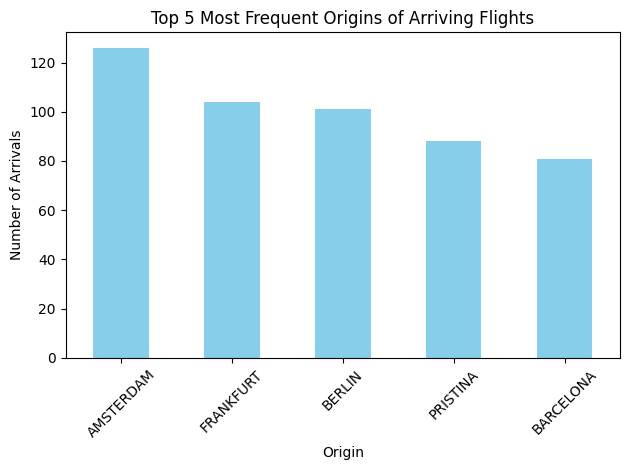

In [47]:
# Find the top five most frequent origins
top_origins = df_airports_2w_arrivals['ForeignAirport'].value_counts().head(5)
# Display the result
print("Top 5 Most Frequent Origins of Arriving Flights:")
print(top_origins)

# Optional: plotting the top origins
top_origins.plot(kind='bar', color='skyblue')
plt.title("Top 5 Most Frequent Origins of Arriving Flights")
plt.xlabel("Origin")
plt.ylabel("Number of Arrivals")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### RQ 2: Top 5 airlines with the highest frequency of arrivals over the past 2 weeks

Top 5 Airlines by Arrival Frequency:
           Number of Arrivals
Airline                      
SWISS                    1182
EASYJET                   624
EDELWEISS                 129
LUFTHANSA                  76
WIZZ AIR                   74


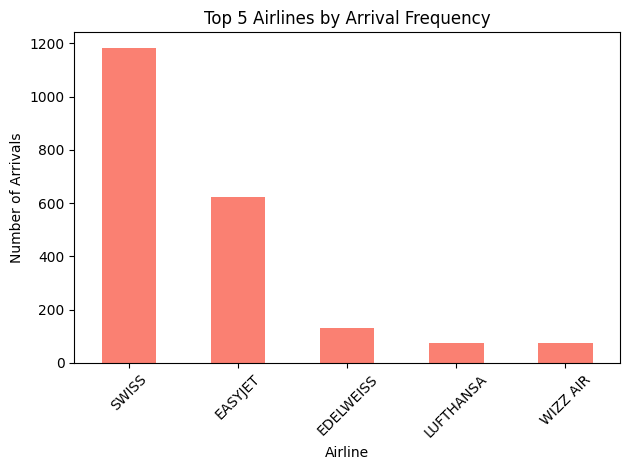

In [45]:
# Find the top five airlines by frequency of arrivals
top_airlines = df_airports_2w_arrivals['Airline'].value_counts().head(5)

# Display the result
print("Top 5 Airlines by Arrival Frequency:")
print(top_airlines.to_frame(name='Number of Arrivals'))

# Optional: plotting the top airlines
top_airlines.plot(kind='bar', color='salmon')
plt.title("Top 5 Airlines by Arrival Frequency")
plt.xlabel("Airline")
plt.ylabel("Number of Arrivals")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### RQ 3: Average delay time for arrivals and departures

In [55]:
# Average delay for arrivals and departures
arrival_delays = df_airports_2w_arrivals['Delay'].mean()
departure_delays = df_airports_2w_departures['Delay'].mean()

print(f"Average delay of arriving flights: {arrival_delays:.2f} minutes")
print(f"Average delay of departing flights: {departure_delays:.2f} minutes")

# Comparison of delay across airports
punctuality_metrics = df_airports_2w.groupby(['LocalAirport', 'Type'])['Delay'].mean().reset_index()
punctuality_metrics.columns = ['Airport', 'Type', 'AverageDelay']

print("Average delay by airport and flight type:")
display(punctuality_metrics)

Average delay of arriving flights: -0.19 minutes
Average delay of departing flights: 4.27 minutes
Average delay by airport and flight type:


,Airport,Type,AverageDelay
0,BASEL,ARRIVAL,-3.448578
1,BASEL,DEPARTURE,2.094726
2,GENEVA,ARRIVAL,-2.123894
3,GENEVA,DEPARTURE,2.108359
4,ZURICH,ARRIVAL,1.630075
5,ZURICH,DEPARTURE,5.600393


Summary of Delay Column for Arrivals after Removing IQR Outliers:
count    3086.000000
mean       -2.162346
std         9.257100
min       -30.000000
25%        -6.000000
50%        -3.000000
75%         1.000000
max        26.000000
Name: Delay, dtype: float64

Summary of Delay Column for Departures after Removing IQR Outliers:
count    3107.000000
mean        1.822659
std         5.368677
min       -15.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        20.000000
Name: Delay, dtype: float64


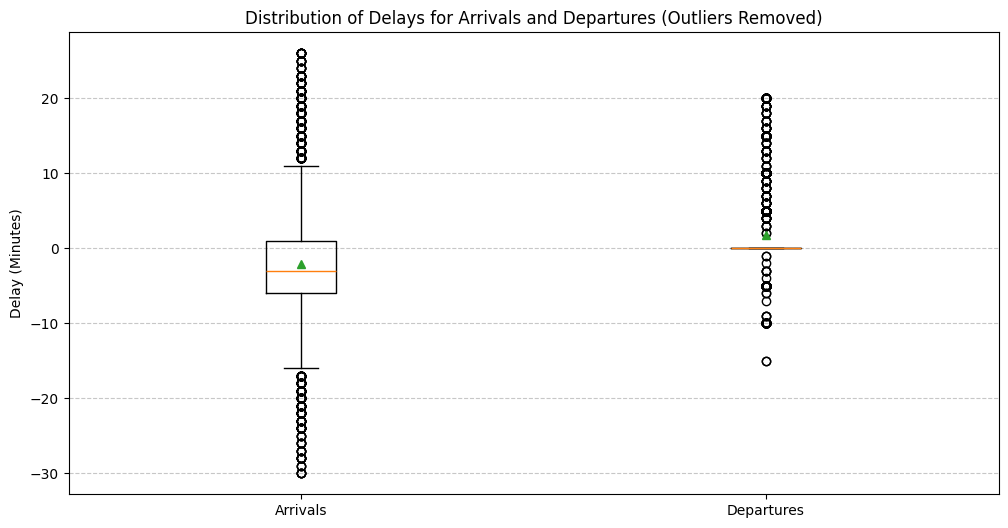

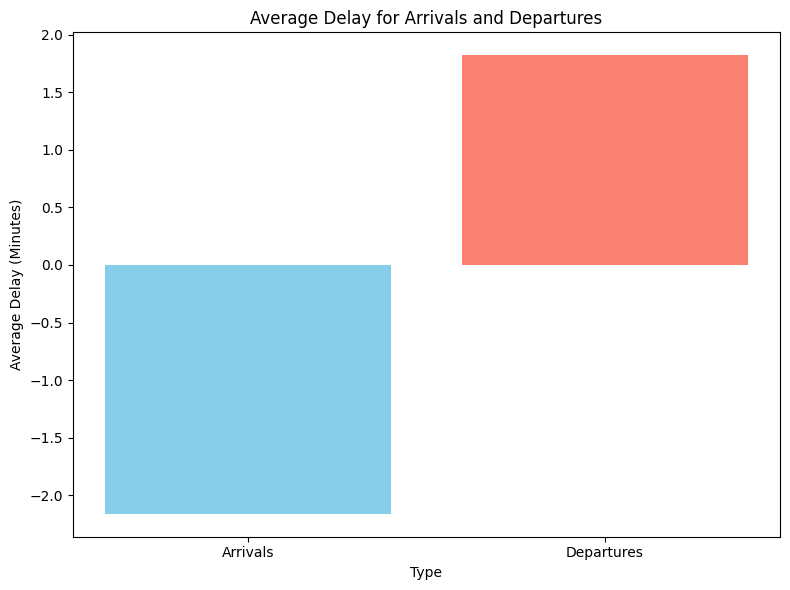

In [57]:
# Optional - let's ignore the outliers 

# ---- Arrivals ----
# Calculate IQR bounds for Arrivals
Q1_arrivals = df_airports_2w_arrivals['Delay'].quantile(0.25)
Q3_arrivals = df_airports_2w_arrivals['Delay'].quantile(0.75)
IQR_arrivals = Q3_arrivals - Q1_arrivals
lower_bound_arrivals = Q1_arrivals - 3 * IQR_arrivals
upper_bound_arrivals = Q3_arrivals + 3 * IQR_arrivals

# Filter out outliers for Arrivals
arrivals_cleaned = df_airports_2w_arrivals[(df_airports_2w_arrivals['Delay'] >= lower_bound_arrivals) & (df_airports_2w_arrivals['Delay'] <= upper_bound_arrivals)]

# ---- Departures ----
# Calculate IQR bounds for Departures
Q1_departures = df_airports_2w_departures['Delay'].quantile(0.25)
Q3_departures = df_airports_2w_departures['Delay'].quantile(0.75)
IQR_departures = Q3_departures - Q1_departures
lower_bound_departures = Q1_departures - 3 * IQR_departures
upper_bound_departures = Q3_departures + 3 * IQR_departures

# Filter out outliers for Departures
departures_cleaned = df_airports_2w_departures[(df_airports_2w_departures['Delay'] >= lower_bound_departures) & (df_airports_2w_departures['Delay'] <= upper_bound_departures)]

# ---- Combine arrivals and departures ----
# Combine the cleaned data for both types
df_cleaned = pd.concat([arrivals_cleaned, departures_cleaned])

# Display summary of the cleaned data to verify that outliers have been removed
print("Summary of Delay Column for Arrivals after Removing IQR Outliers:")
print(arrivals_cleaned['Delay'].describe())

print("\nSummary of Delay Column for Departures after Removing IQR Outliers:")
print(departures_cleaned['Delay'].describe())

# Plotting boxplot for Delay distributions after removing outliers
plt.figure(figsize=(12, 6))
plt.boxplot(
    [arrivals_cleaned['Delay'], departures_cleaned['Delay']],
    tick_labels=['Arrivals', 'Departures'],
    showmeans=True
)
plt.title("Distribution of Delays for Arrivals and Departures (Outliers Removed)")
plt.ylabel("Delay (Minutes)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Bar plot for Average Delay
average_delays = {
    'Arrivals': arrivals_cleaned['Delay'].mean(),
    'Departures': departures_cleaned['Delay'].mean()
}

plt.figure(figsize=(8, 6))
plt.bar(average_delays.keys(), average_delays.values(), color=['skyblue', 'salmon'])
plt.title("Average Delay for Arrivals and Departures")
plt.xlabel("Type")
plt.ylabel("Average Delay (Minutes)")
plt.tight_layout()
plt.show()


### BONUS: Top 10 most frequet airlines and their ranking on average delay time for arrivals and departures

Top 10 Airlines with Most Average Delay in Arrivals:
Airline
LUFTHANSA_NEU      6.666667
EURO               4.606061
KLM                1.927536
SWISS              1.775804
BRITISH            0.730769
EDELWEISS         -0.286822
EASYJET           -2.713141
LUFTHANSA         -3.434211
WIZZ AIR          -3.472973
BRITISH AIRWAYS   -3.703704
Name: Delay, dtype: float64

Top 10 Airlines with Most Average Delay in Departures:
Airline
LUFTHANSA_NEU      9.238095
EURO               8.030303
EDELWEISS          7.382353
SWISS              4.926385
LUFTHANSA          3.880000
WIZZ AIR           3.626667
KLM                3.521127
BRITISH            3.169811
EASYJET            1.866774
BRITISH AIRWAYS    0.363636
Name: Delay, dtype: float64


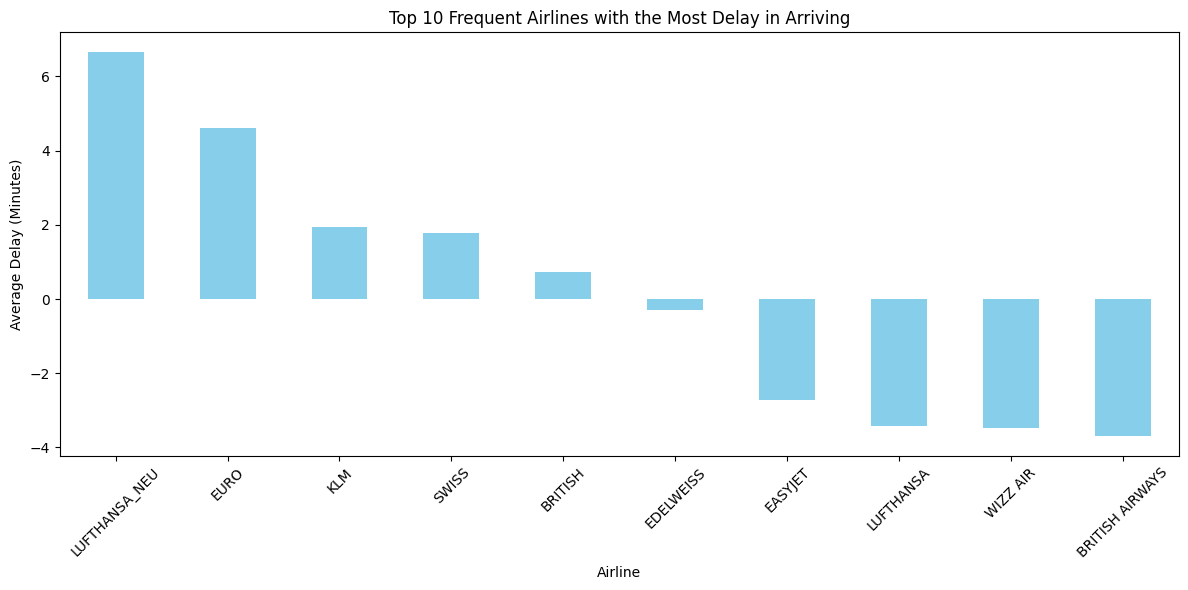

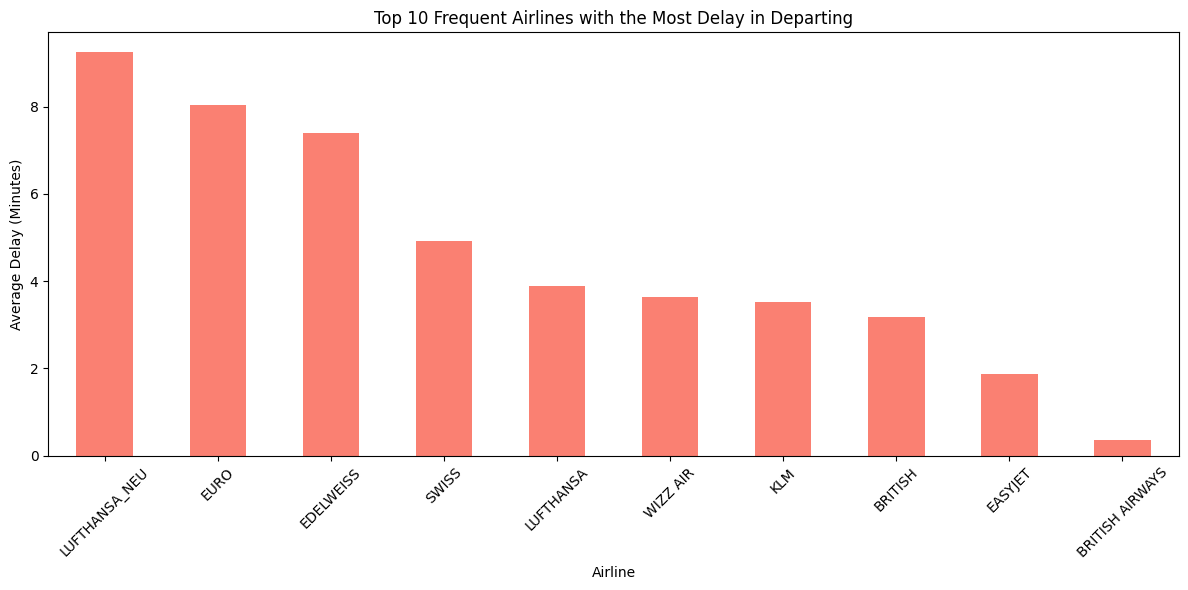

In [51]:
# Identify the top 10 airlines with the greatest frequency in arrivals
top_10_arrival_airlines = df_airports_2w_arrivals['Airline'].value_counts().head(10).index

# Identify the top 10 airlines with the greatest frequency in departures
top_10_departure_airlines = df_airports_2w_departures['Airline'].value_counts().head(10).index

# Combine these lists to get the union of airlines appearing in either top 10 list
top_airlines = top_10_arrival_airlines.union(top_10_departure_airlines)

# Filter the main DataFrame to only include rows for these top airlines
top_airlines_df = df_airports_2w[df_airports_2w['Airline'].isin(top_airlines)]

# Calculate the average delay grouped by Airline and Type
average_delay_by_airline_and_type = top_airlines_df.groupby(['Airline', 'Type'])['Delay'].mean()

# Separate arrivals and departures, then rank them within each group
average_delay_arrivals = average_delay_by_airline_and_type.xs('ARRIVAL', level='Type').sort_values(ascending=False)
average_delay_departures = average_delay_by_airline_and_type.xs('DEPARTURE', level='Type').sort_values(ascending=False)

# Display the top 10 airlines with the most average delay in arrivals and departures
print("Top 10 Airlines with Most Average Delay in Arrivals:")
print(average_delay_arrivals.head(10))

print("\nTop 10 Airlines with Most Average Delay in Departures:")
print(average_delay_departures.head(10))

# Optional: plotting the results for Arrivals
plt.figure(figsize=(12, 6))
average_delay_arrivals.head(10).plot(kind='bar', color='skyblue')
plt.title("Top 10 Frequent Airlines with the Most Delay in Arriving")
plt.xlabel("Airline")
plt.ylabel("Average Delay (Minutes)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plotting the results for Departures
plt.figure(figsize=(12, 6))
average_delay_departures.head(10).plot(kind='bar', color='salmon')
plt.title("Top 10 Frequent Airlines with the Most Delay in Departing")
plt.xlabel("Airline")
plt.ylabel("Average Delay (Minutes)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
